# **EventTime based sessionization**

https://towardsdatascience.com/spark-3-2-session-windowing-feature-for-streaming-data-e404d92e267


In [1]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()
spark.version

'3.5.1'

## **Types of Windowing Functions**


With the newest updates, Spark 3.2 contains three unique types of windowing functions
* Tumbling (fixed)
* Sliding
* Session

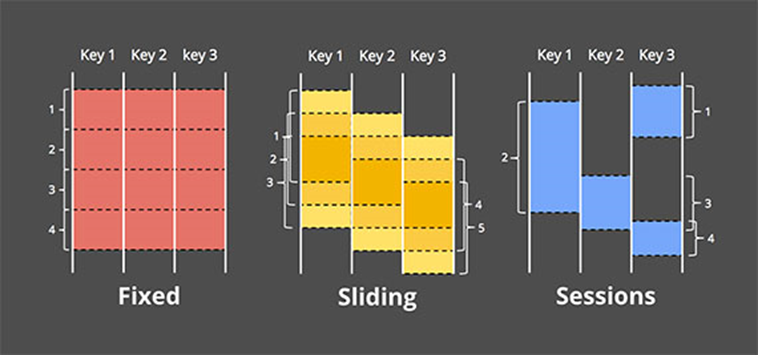

In [2]:
# Sample Data is generated for windowing examples
windowingData = (
    ("12", "2019-01-02 15:30:00"),
    ("12",  "2019-01-02 15:30:30"),
    ("12",  "2019-01-02 15:31:00"),
    ("12",  "2019-01-02 15:31:50"),
    ("12",  "2019-01-02 15:31:55"),
    ("16",  "2019-01-02 15:33:00"),
    ("16",  "2019-01-02 15:35:20"),
    ("16",  "2019-01-02 15:37:00"),
    ("20",  "2019-01-02 15:30:30"),
    ("20",  "2019-01-02 15:31:00"),
    ("20",  "2019-01-02 15:31:50"),
    ("20",  "2019-01-02 15:31:55"),
    ("20",  "2019-01-02 15:33:00"),
    ("20",  "2019-01-02 15:35:20"),
    ("20",  "2019-01-02 15:37:00"),
    ("20",  "2019-01-02 15:40:00"),
    ("20",  "2019-01-02 15:45:00"),
    ("20",  "2019-01-02 15:46:00"),
    ("20",  "2019-01-02 15:47:30"),
    ("20",  "2019-01-02 15:48:00"),
    ("20",  "2019-01-02 15:48:10"),
    ("20",  "2019-01-02 15:48:20"),
    ("20",  "2019-01-02 15:48:30"),
    ("20",  "2019-01-02 15:50:00"),
    ("20",  "2019-01-02 15:53:00"),
    ("20",  "2019-01-02 15:54:30"),
    ("20",  "2019-01-02 15:55:00"),
    ("22",  "2019-01-02 15:50:30"),
    ("22",  "2019-01-02 15:52:00"),
    ("22",  "2019-01-02 15:50:30"),
    ("22",  "2019-01-02 15:52:00"),
    ("22",  "2019-01-02 15:50:30"),
    ("12",  "2019-01-02 15:50:30"),
    ("22",  "2019-01-02 15:52:00"))

columns = ["eventId", "timeReceived"]

In [3]:
# create Spark Dataframe out of data
windowing_df = spark.createDataFrame(data = windowingData, schema = columns)
windowing_df.printSchema()
windowing_df.show(100, truncate=False)

root
 |-- eventId: string (nullable = true)
 |-- timeReceived: string (nullable = true)

+-------+-------------------+
|eventId|timeReceived       |
+-------+-------------------+
|12     |2019-01-02 15:30:00|
|12     |2019-01-02 15:30:30|
|12     |2019-01-02 15:31:00|
|12     |2019-01-02 15:31:50|
|12     |2019-01-02 15:31:55|
|16     |2019-01-02 15:33:00|
|16     |2019-01-02 15:35:20|
|16     |2019-01-02 15:37:00|
|20     |2019-01-02 15:30:30|
|20     |2019-01-02 15:31:00|
|20     |2019-01-02 15:31:50|
|20     |2019-01-02 15:31:55|
|20     |2019-01-02 15:33:00|
|20     |2019-01-02 15:35:20|
|20     |2019-01-02 15:37:00|
|20     |2019-01-02 15:40:00|
|20     |2019-01-02 15:45:00|
|20     |2019-01-02 15:46:00|
|20     |2019-01-02 15:47:30|
|20     |2019-01-02 15:48:00|
|20     |2019-01-02 15:48:10|
|20     |2019-01-02 15:48:20|
|20     |2019-01-02 15:48:30|
|20     |2019-01-02 15:50:00|
|20     |2019-01-02 15:53:00|
|20     |2019-01-02 15:54:30|
|20     |2019-01-02 15:55:00|
|22     |20

In [4]:
windowing_df.sort("timeReceived").show()

+-------+-------------------+
|eventId|       timeReceived|
+-------+-------------------+
|     12|2019-01-02 15:30:00|
|     20|2019-01-02 15:30:30|
|     12|2019-01-02 15:30:30|
|     12|2019-01-02 15:31:00|
|     20|2019-01-02 15:31:00|
|     20|2019-01-02 15:31:50|
|     12|2019-01-02 15:31:50|
|     12|2019-01-02 15:31:55|
|     20|2019-01-02 15:31:55|
|     16|2019-01-02 15:33:00|
|     20|2019-01-02 15:33:00|
|     16|2019-01-02 15:35:20|
|     20|2019-01-02 15:35:20|
|     20|2019-01-02 15:37:00|
|     16|2019-01-02 15:37:00|
|     20|2019-01-02 15:40:00|
|     20|2019-01-02 15:45:00|
|     20|2019-01-02 15:46:00|
|     20|2019-01-02 15:47:30|
|     20|2019-01-02 15:48:00|
+-------+-------------------+
only showing top 20 rows



## **Tumbling window**
The tumbling windows can be represented as a group of equally partitioned, adjacent time periods without having any intersecting intervals. The inputted data may be subject to an individual window.

In [5]:
from pyspark.sql.functions import *

tumblingWindows = (windowing_df
                   .withWatermark("timeReceived", "10 minutes")
                   .groupBy("eventId", window("timeReceived", "5 minutes"))
                   .count()
                  )

tumblingWindows.show(truncate = False)

+-------+------------------------------------------+-----+
|eventId|window                                    |count|
+-------+------------------------------------------+-----+
|16     |{2019-01-02 15:35:00, 2019-01-02 15:40:00}|2    |
|12     |{2019-01-02 15:30:00, 2019-01-02 15:35:00}|5    |
|16     |{2019-01-02 15:30:00, 2019-01-02 15:35:00}|1    |
|20     |{2019-01-02 15:40:00, 2019-01-02 15:45:00}|1    |
|20     |{2019-01-02 15:30:00, 2019-01-02 15:35:00}|5    |
|20     |{2019-01-02 15:35:00, 2019-01-02 15:40:00}|2    |
|20     |{2019-01-02 15:50:00, 2019-01-02 15:55:00}|3    |
|20     |{2019-01-02 15:45:00, 2019-01-02 15:50:00}|7    |
|22     |{2019-01-02 15:50:00, 2019-01-02 15:55:00}|6    |
|12     |{2019-01-02 15:50:00, 2019-01-02 15:55:00}|1    |
|20     |{2019-01-02 15:55:00, 2019-01-02 16:00:00}|1    |
+-------+------------------------------------------+-----+



In [6]:
from pyspark.sql.functions import *

tumblingWindows = (windowing_df
                   .withWatermark("timeReceived", "10 minutes")
                   .groupBy(window("timeReceived", "5 minutes"))
                   .count()
                  )

tumblingWindows.show(truncate = False)

+------------------------------------------+-----+
|window                                    |count|
+------------------------------------------+-----+
|{2019-01-02 15:30:00, 2019-01-02 15:35:00}|11   |
|{2019-01-02 15:35:00, 2019-01-02 15:40:00}|4    |
|{2019-01-02 15:40:00, 2019-01-02 15:45:00}|1    |
|{2019-01-02 15:45:00, 2019-01-02 15:50:00}|7    |
|{2019-01-02 15:50:00, 2019-01-02 15:55:00}|10   |
|{2019-01-02 15:55:00, 2019-01-02 16:00:00}|1    |
+------------------------------------------+-----+



In [7]:
from pyspark.sql.functions import *

tumblingWindows = (windowing_df
                   .withWatermark("timeReceived", "10 minutes")
                   .select("eventId",
                           "timeReceived",
                           window("timeReceived", "5 minutes").alias("tumbling")
                          )
                  )

tumblingWindows.show(truncate = False)

+-------+-------------------+------------------------------------------+
|eventId|timeReceived       |tumbling                                  |
+-------+-------------------+------------------------------------------+
|12     |2019-01-02 15:30:00|{2019-01-02 15:30:00, 2019-01-02 15:35:00}|
|12     |2019-01-02 15:30:30|{2019-01-02 15:30:00, 2019-01-02 15:35:00}|
|12     |2019-01-02 15:31:00|{2019-01-02 15:30:00, 2019-01-02 15:35:00}|
|12     |2019-01-02 15:31:50|{2019-01-02 15:30:00, 2019-01-02 15:35:00}|
|12     |2019-01-02 15:31:55|{2019-01-02 15:30:00, 2019-01-02 15:35:00}|
|16     |2019-01-02 15:33:00|{2019-01-02 15:30:00, 2019-01-02 15:35:00}|
|16     |2019-01-02 15:35:20|{2019-01-02 15:35:00, 2019-01-02 15:40:00}|
|16     |2019-01-02 15:37:00|{2019-01-02 15:35:00, 2019-01-02 15:40:00}|
|20     |2019-01-02 15:30:30|{2019-01-02 15:30:00, 2019-01-02 15:35:00}|
|20     |2019-01-02 15:31:00|{2019-01-02 15:30:00, 2019-01-02 15:35:00}|
|20     |2019-01-02 15:31:50|{2019-01-02 15:30:00, 

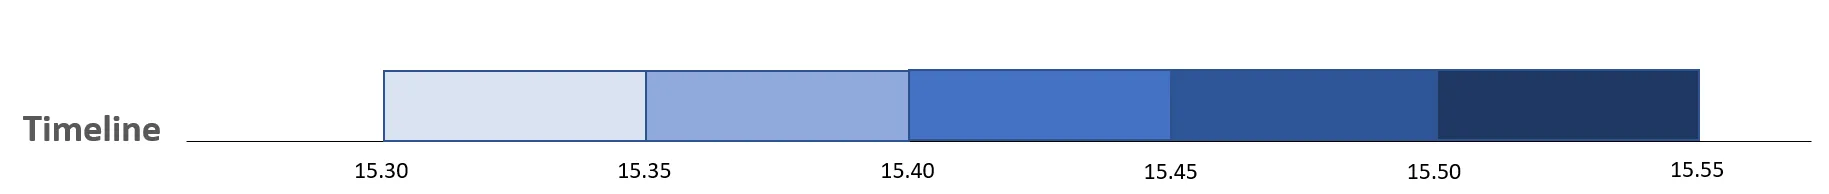

## **Sliding window**
The sliding windows may have intersecting time periods when the time span contains a shorter interval than the range of the window. In such cases, timestamped items can be found in more than one window.

In [8]:
from pyspark.sql.functions import *

slidingWindows = (windowing_df
                  .withWatermark("timeReceived", "10 minutes")
                  .groupBy("eventId", window("timeReceived", "10 minutes", "5 minutes"))
                  .count()
                 )

slidingWindows.show(truncate = False)

+-------+------------------------------------------+-----+
|eventId|window                                    |count|
+-------+------------------------------------------+-----+
|16     |{2019-01-02 15:25:00, 2019-01-02 15:35:00}|1    |
|12     |{2019-01-02 15:25:00, 2019-01-02 15:35:00}|5    |
|16     |{2019-01-02 15:30:00, 2019-01-02 15:40:00}|3    |
|16     |{2019-01-02 15:35:00, 2019-01-02 15:45:00}|2    |
|12     |{2019-01-02 15:30:00, 2019-01-02 15:40:00}|5    |
|20     |{2019-01-02 15:30:00, 2019-01-02 15:40:00}|7    |
|20     |{2019-01-02 15:40:00, 2019-01-02 15:50:00}|8    |
|20     |{2019-01-02 15:25:00, 2019-01-02 15:35:00}|5    |
|20     |{2019-01-02 15:35:00, 2019-01-02 15:45:00}|3    |
|20     |{2019-01-02 15:50:00, 2019-01-02 16:00:00}|4    |
|20     |{2019-01-02 15:45:00, 2019-01-02 15:55:00}|10   |
|20     |{2019-01-02 15:55:00, 2019-01-02 16:05:00}|1    |
|12     |{2019-01-02 15:45:00, 2019-01-02 15:55:00}|1    |
|22     |{2019-01-02 15:45:00, 2019-01-02 15:55:00}|6   

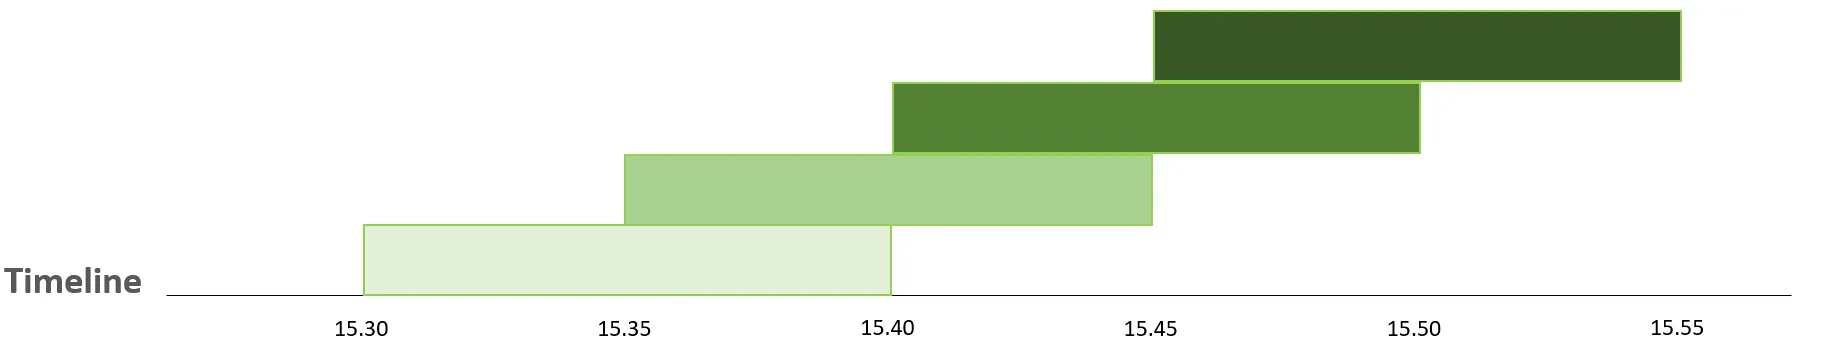

## **Session window**
Session windows may contain the nature of a dynamic length by means of the window size relative to the inputting item type.

In [9]:
  from pyspark.sql.functions import *

  sessionWindows = (windowing_df
                    .withWatermark("timeReceived", "10 minutes")
                    .groupBy("eventId", session_window("timeReceived", "5 minutes"))
                    .count()
                   )

  sessionWindows.show(truncate = False)

+-------+------------------------------------------+-----+
|eventId|session_window                            |count|
+-------+------------------------------------------+-----+
|12     |{2019-01-02 15:30:00, 2019-01-02 15:36:55}|5    |
|12     |{2019-01-02 15:50:30, 2019-01-02 15:55:30}|1    |
|16     |{2019-01-02 15:33:00, 2019-01-02 15:42:00}|3    |
|20     |{2019-01-02 15:30:30, 2019-01-02 16:00:00}|19   |
|22     |{2019-01-02 15:50:30, 2019-01-02 15:57:00}|6    |
+-------+------------------------------------------+-----+



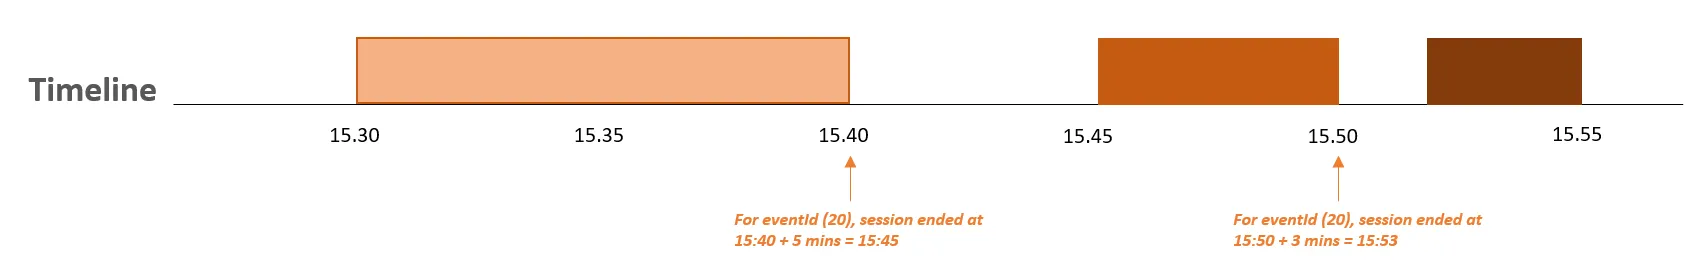

### Dynamic Gap Period on Session Window
The session window functionality has an additional feature which is called **dynamic gap duration**. The period of the session may have various values when requested. The sessions that have an overlapping behavior can be grouped into a single session. The total duration of this session will be equal to the sum of the time duration of the intersecting events.

In [10]:
from pyspark.sql.functions import *

windowedCountsDF = (windowing_df
                    .withWatermark("timeReceived", "10 minutes")
                    .groupBy(windowing_df.eventId, session_window(windowing_df.timeReceived, \
    when(windowing_df.eventId == "20", "10 seconds").when(windowing_df.eventId == "12","30 seconds")
                                                                  .otherwise("10 minutes")))
                    .count())

windowedCountsDF.show(100, truncate = False)

+-------+------------------------------------------+-----+
|eventId|session_window                            |count|
+-------+------------------------------------------+-----+
|12     |{2019-01-02 15:30:00, 2019-01-02 15:31:30}|3    |
|12     |{2019-01-02 15:31:50, 2019-01-02 15:32:25}|2    |
|12     |{2019-01-02 15:50:30, 2019-01-02 15:51:00}|1    |
|16     |{2019-01-02 15:33:00, 2019-01-02 15:47:00}|3    |
|20     |{2019-01-02 15:30:30, 2019-01-02 15:30:40}|1    |
|20     |{2019-01-02 15:31:00, 2019-01-02 15:31:10}|1    |
|20     |{2019-01-02 15:31:50, 2019-01-02 15:32:05}|2    |
|20     |{2019-01-02 15:33:00, 2019-01-02 15:33:10}|1    |
|20     |{2019-01-02 15:35:20, 2019-01-02 15:35:30}|1    |
|20     |{2019-01-02 15:37:00, 2019-01-02 15:37:10}|1    |
|20     |{2019-01-02 15:40:00, 2019-01-02 15:40:10}|1    |
|20     |{2019-01-02 15:45:00, 2019-01-02 15:45:10}|1    |
|20     |{2019-01-02 15:46:00, 2019-01-02 15:46:10}|1    |
|20     |{2019-01-02 15:47:30, 2019-01-02 15:47:40}|1   